# Doom vs Animal Crossing Meme Classification
**Goal:** Binary image classification — Doom subreddit (label 0) vs Animal Crossing subreddit (label 1)  
**Metric:** Balanced Accuracy  
**Constraints:** From-scratch CNN only (no pretrained models, no external data)  

**Strategy to beat 0.817 BA:**
- Deep custom CNN with residual-style blocks (built from scratch)
- Strong data augmentation pipeline
- Class-balanced training with class weights
- Cosine annealing LR scheduler + early stopping
- Test-Time Augmentation (TTA) for robust predictions
- Ensemble of multiple training folds (optional, if time permits)

# Cell 1: Install Dependencies

In [16]:
import sys
!{sys.executable} -m pip install opencv-python
!{sys.executable} -m pip install -q tensorflow scikit-learn pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


# Cell 2: Imports & Reproducibility

In [17]:
import os, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, LearningRateScheduler
)
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


# Cell 3: Configuration

In [18]:
# ─────────────────────────────────────────────────────────────
#  CHANGE THIS to your local path where the dataset lives
# ─────────────────────────────────────────────────────────────
BASE_DIR = '.'          # e.g. '/Users/yourname/Downloads/knu_ml'
IMG_DIR  = os.path.join(BASE_DIR, 'img')

# Model / training config
IMG_SIZE    = 128          # resize all images to IMG_SIZE x IMG_SIZE
BATCH_SIZE  = 32
EPOCHS      = 80           # will early-stop before this
LR_INIT     = 3e-4
N_FOLDS     = 5            # for cross-validation ensemble
TTA_STEPS   = 10           # test-time augmentation forward passes
DROPOUT_RATE= 0.4
L2_REG      = 1e-4

print(f'Image size : {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size : {BATCH_SIZE}')
print(f'Max epochs : {EPOCHS}')
print(f'TTA steps  : {TTA_STEPS}')

Image size : 128x128
Batch size : 32
Max epochs : 80
TTA steps  : 10


# Cell 4: Load Labels

In [19]:
TRAIN_LABEL = pd.read_csv(os.path.join(BASE_DIR, 'train-label.csv'), index_col='id')
TEST_LABEL  = pd.read_csv(os.path.join(BASE_DIR, 'test-label.csv'),  index_col='id')

print('Train samples:', len(TRAIN_LABEL))
print('Test  samples:', len(TEST_LABEL))
print('\nLabel distribution (train):')
print(TRAIN_LABEL['label'].value_counts().sort_index())
print('\nClass names: 0=Doom, 1=Animal Crossing')

# Quick sanity check — verify images exist
missing = [f for f in TRAIN_LABEL['file'] if not os.path.exists(os.path.join(IMG_DIR, f))]
print(f'\nMissing training images: {len(missing)}')

Train samples: 1385
Test  samples: 1386

Label distribution (train):
label
0    707
1    678
Name: count, dtype: int64

Class names: 0=Doom, 1=Animal Crossing

Missing training images: 0


# Cell 5: EDA — Class Distribution & Sample Images

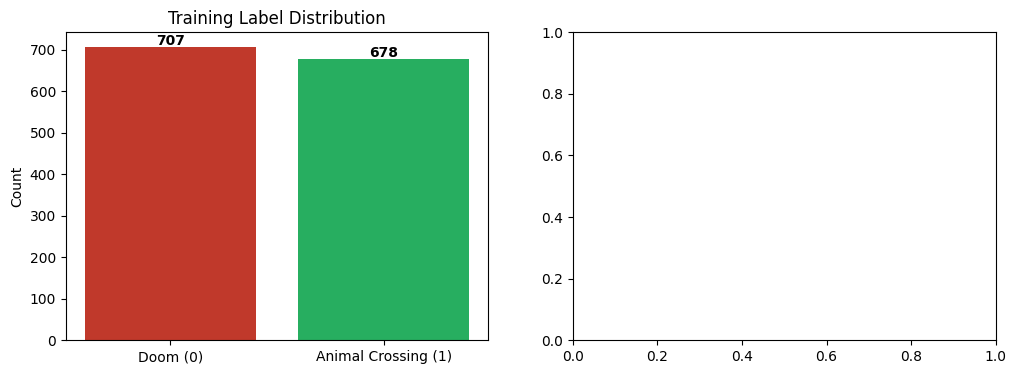

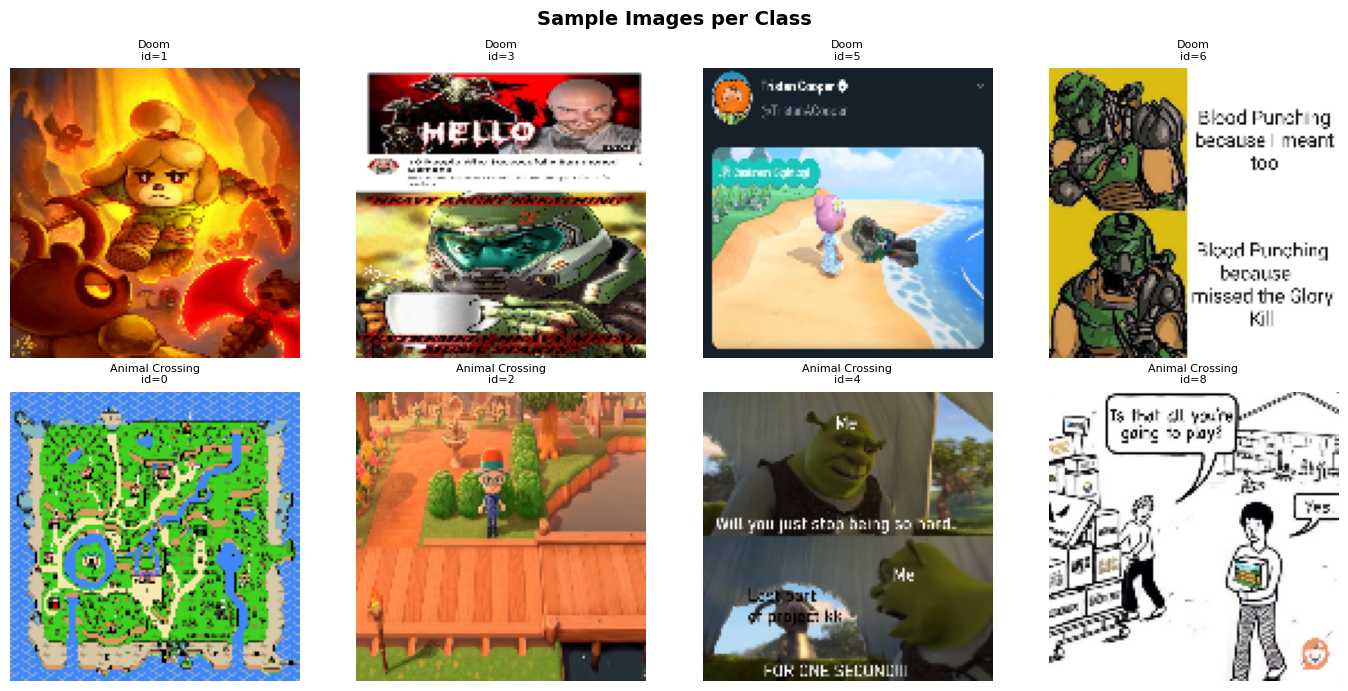

In [20]:
# ── Class distribution bar chart ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = TRAIN_LABEL['label'].value_counts().sort_index()
axes[0].bar(['Doom (0)', 'Animal Crossing (1)'], counts.values, color=['#c0392b','#27ae60'])
axes[0].set_title('Training Label Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# ── Sample images ──────────────────────────────────────────────
import cv2

def load_img(path, size=128):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    return img

doom_ids  = TRAIN_LABEL[TRAIN_LABEL['label']==0].index[:4]
acnh_ids  = TRAIN_LABEL[TRAIN_LABEL['label']==1].index[:4]
sample_rows = [(0, i) for i in doom_ids] + [(1, i) for i in acnh_ids]

fig2, axes2 = plt.subplots(2, 4, figsize=(14, 7))
for ax, (label, idx) in zip(axes2.flat, sample_rows):
    fname = TRAIN_LABEL.loc[idx, 'file']
    path  = os.path.join(IMG_DIR, fname)
    try:
        img = load_img(path)
        ax.imshow(img)
    except:
        ax.text(0.5, 0.5, 'N/A', ha='center')
    class_name = 'Doom' if label == 0 else 'Animal Crossing'
    ax.set_title(f'{class_name}\nid={idx}', fontsize=8)
    ax.axis('off')

plt.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Cell 6: Dataset Builder (tf.data pipeline)

In [21]:
def parse_image(path, label, img_size=IMG_SIZE, augment=False):
    """Load and optionally augment a single image."""
    raw   = tf.io.read_file(path)
    image = tf.image.decode_image(raw, channels=3, expand_animations=False)
    image = tf.image.resize(image, [img_size, img_size])
    image = tf.cast(image, tf.float32) / 255.0   # normalize to [0,1]

    if augment:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_flip_up_down(image)
        image = tf.image.random_brightness(image, 0.25)
        image = tf.image.random_contrast(image, 0.75, 1.25)
        image = tf.image.random_saturation(image, 0.75, 1.25)
        image = tf.image.random_hue(image, 0.08)
        # Random 90° rotation
        k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
        image = tf.image.rot90(image, k)
        image = tf.clip_by_value(image, 0.0, 1.0)

    return image, label


def make_dataset(files, labels, img_size=IMG_SIZE, batch_size=BATCH_SIZE,
                 augment=False, shuffle=False, repeat=False):
    """Build a tf.data.Dataset from file paths and integer labels."""
    paths_tensor  = tf.constant(files,  dtype=tf.string)
    labels_tensor = tf.constant(labels, dtype=tf.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths_tensor, labels_tensor))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(files), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(
        lambda p, l: parse_image(p, l, img_size=img_size, augment=augment),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if repeat:
        ds = ds.repeat()

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


def paths_from_df(df, img_dir):
    """Return full file paths and labels arrays from a label dataframe."""
    paths  = [os.path.join(img_dir, f) for f in df['file']]
    labels = df['label'].values.astype(np.int32)
    return np.array(paths), labels


# Quick test
all_paths, all_labels = paths_from_df(TRAIN_LABEL, IMG_DIR)
test_paths, _         = paths_from_df(TEST_LABEL,  IMG_DIR)

print(f'Total train paths : {len(all_paths)}')
print(f'Total test paths  : {len(test_paths)}')
print(f'Label dtype       : {all_labels.dtype}')

Total train paths : 1385
Total test paths  : 1386
Label dtype       : int32


# Cell 7: Model Architecture — Deep Custom CNN with Residual Blocks

In [22]:
def conv_bn_relu(x, filters, kernel=3, stride=1, l2=L2_REG):
    """Conv → BatchNorm → ReLU block."""
    x = layers.Conv2D(
        filters, kernel, strides=stride, padding='same',
        use_bias=False,
        kernel_regularizer=regularizers.l2(l2)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x


def residual_block(x, filters, downsample=False, l2=L2_REG):
    """
    Custom residual block (built from scratch — no pretrained weights).
    If downsample=True, halves spatial dimensions via stride=2.
    """
    stride  = 2 if downsample else 1
    shortcut = x

    # Main path
    x = conv_bn_relu(x, filters, kernel=3, stride=stride, l2=l2)
    x = layers.Conv2D(
        filters, 3, strides=1, padding='same',
        use_bias=False,
        kernel_regularizer=regularizers.l2(l2)
    )(x)
    x = layers.BatchNormalization()(x)

    # Shortcut projection if shapes differ
    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(
            filters, 1, strides=stride, padding='same',
            use_bias=False,
            kernel_regularizer=regularizers.l2(l2)
        )(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x


def build_model(img_size=IMG_SIZE, dropout=DROPOUT_RATE, l2=L2_REG):
    """
    Builds a deep from-scratch CNN (no pretrained weights) inspired by
    ResNet-style residual connections. ~2M parameters.
    """
    inputs = keras.Input(shape=(img_size, img_size, 3))

    # ── Stem ────────────────────────────────────────────────────
    x = conv_bn_relu(inputs, 32, kernel=3, l2=l2)           # 128x128x32
    x = conv_bn_relu(x,      32, kernel=3, l2=l2)           # 128x128x32
    x = layers.MaxPooling2D(2)(x)                            # 64x64x32

    # ── Stage 1 ─────────────────────────────────────────────────
    x = residual_block(x, 64,  downsample=False, l2=l2)     # 64x64x64
    x = residual_block(x, 64,  downsample=False, l2=l2)     # 64x64x64
    x = residual_block(x, 64,  downsample=True,  l2=l2)     # 32x32x64

    # ── Stage 2 ─────────────────────────────────────────────────
    x = residual_block(x, 128, downsample=False, l2=l2)     # 32x32x128
    x = residual_block(x, 128, downsample=False, l2=l2)     # 32x32x128
    x = residual_block(x, 128, downsample=True,  l2=l2)     # 16x16x128

    # ── Stage 3 ─────────────────────────────────────────────────
    x = residual_block(x, 256, downsample=False, l2=l2)     # 16x16x256
    x = residual_block(x, 256, downsample=False, l2=l2)     # 16x16x256
    x = residual_block(x, 256, downsample=True,  l2=l2)     # 8x8x256

    # ── Stage 4 ─────────────────────────────────────────────────
    x = residual_block(x, 512, downsample=False, l2=l2)     # 8x8x512
    x = residual_block(x, 512, downsample=True,  l2=l2)     # 4x4x512

    # ── Head ────────────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(dropout * 0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)      # binary output

    model = keras.Model(inputs, outputs)
    return model


# Preview
preview = build_model()
preview.summary()
del preview

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,432 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,864 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │      2,048 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ add[0][0]       

 Total params: 13,239,905 (50.51 MB)

 Trainable params: 13,225,953 (50.45 MB)

 Non-trainable params: 13,952 (54.50 KB)

# Cell 8: Cosine Annealing LR Schedule

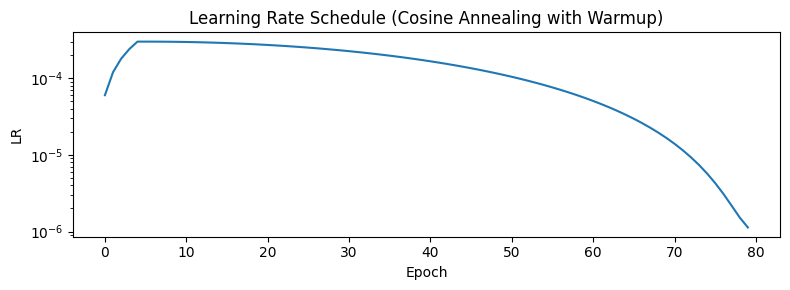

In [23]:
def cosine_annealing_schedule(epoch, lr, warmup=5, epochs=EPOCHS, lr_min=1e-6):
    """Linear warmup then cosine decay."""
    if epoch < warmup:
        return LR_INIT * (epoch + 1) / warmup
    progress = (epoch - warmup) / max(1, (epochs - warmup))
    return lr_min + 0.5 * (LR_INIT - lr_min) * (1 + np.cos(np.pi * progress))

# Visualize the schedule
lrs = [cosine_annealing_schedule(e, None) for e in range(EPOCHS)]
plt.figure(figsize=(8, 3))
plt.plot(lrs)
plt.title('Learning Rate Schedule (Cosine Annealing with Warmup)')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.yscale('log')
plt.tight_layout()
plt.show()

# Cell 9: Cross-Validation Training with Ensemble

In [24]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Store out-of-fold predictions and test predictions
oof_preds  = np.zeros(len(all_paths))    # probability for each train sample
test_preds = np.zeros(len(test_paths))   # averaged over folds

fold_histories = []
fold_val_ba    = []

for fold, (train_idx, val_idx) in enumerate(skf.split(all_paths, all_labels)):
    print(f'\n{"="*60}')
    print(f'  FOLD {fold+1} / {N_FOLDS}')
    print(f'{"="*60}')

    tr_paths, tr_labels = all_paths[train_idx], all_labels[train_idx]
    va_paths, va_labels = all_paths[val_idx],   all_labels[val_idx]

    # ── Class weights (combat imbalance) ─────────────────────────
    cw_values = compute_class_weight('balanced',
                                     classes=np.unique(tr_labels),
                                     y=tr_labels)
    class_weight = {int(k): float(v) for k, v in zip(np.unique(tr_labels), cw_values)}
    print(f'  Class weights: {class_weight}')

    # ── Datasets ─────────────────────────────────────────────────
    train_ds = make_dataset(tr_paths, tr_labels, augment=True,  shuffle=True)
    val_ds   = make_dataset(va_paths, va_labels, augment=False, shuffle=False)

    # ── Build fresh model ─────────────────────────────────────────
    tf.keras.backend.clear_session()
    model = build_model()
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR_INIT),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # ── Callbacks ─────────────────────────────────────────────────
    ckpt_path = f'best_model_fold{fold+1}.h5'
    callbacks = [
        ModelCheckpoint(ckpt_path, monitor='val_loss',
                        save_best_only=True, verbose=0),
        EarlyStopping(monitor='val_loss', patience=15,
                      restore_best_weights=True, verbose=1),
        LearningRateScheduler(
            lambda e, lr: cosine_annealing_schedule(e, lr), verbose=0
        )
    ]

    # ── Train ─────────────────────────────────────────────────────
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=2
    )
    fold_histories.append(history)

    # ── Validation OOF predictions ────────────────────────────────
    val_probs = model.predict(val_ds, verbose=0).flatten()
    val_preds = (val_probs >= 0.5).astype(int)
    ba = balanced_accuracy_score(va_labels, val_preds)
    fold_val_ba.append(ba)
    oof_preds[val_idx] = val_probs
    print(f'  Fold {fold+1} Validation Balanced Accuracy: {ba:.4f}')

    # ── Test predictions (TTA) ────────────────────────────────────
    test_ds_aug = make_dataset(test_paths,
                               np.zeros(len(test_paths), dtype=np.int32),
                               augment=True, shuffle=False)
    test_ds_clean = make_dataset(test_paths,
                                 np.zeros(len(test_paths), dtype=np.int32),
                                 augment=False, shuffle=False)

    tta_preds = model.predict(test_ds_clean, verbose=0).flatten()
    for _ in range(TTA_STEPS - 1):
        tta_preds += model.predict(test_ds_aug, verbose=0).flatten()
    tta_preds /= TTA_STEPS

    test_preds += tta_preds / N_FOLDS   # average over folds

print(f'\n{"="*60}')
print(f'Cross-Validation Summary:')
for i, ba in enumerate(fold_val_ba):
    print(f'  Fold {i+1}: BA = {ba:.4f}')
print(f'  Mean BA = {np.mean(fold_val_ba):.4f} ± {np.std(fold_val_ba):.4f}')

# Full OOF balanced accuracy
oof_labels_pred = (oof_preds >= 0.5).astype(int)
oof_ba = balanced_accuracy_score(all_labels, oof_labels_pred)
print(f'  OOF   BA = {oof_ba:.4f}')


  FOLD 1 / 5
  Class weights: {0: 0.9787985865724381, 1: 1.022140221402214}
Epoch 1/80


W0000 00:00:1780195021.710856  225117 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780195022.275000  225122 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780195022.742822  225123 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780195024.099167  225115 png_io.cc:96] PNG warning: iCCP: extra compressed data
W0000 00:00:1780195024.478825  225122 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780195053.055915  225122 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780195081.498651  225115 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780195118.543387  227508 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780195120.888486  227506 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780195120.893825  227512 png_io.cc:96] PNG warning: iCCP: extra compressed data


35/35 - 115s - 3s/step - accuracy: 0.5009 - loss: 1.4911 - val_accuracy: 0.5090 - val_loss: 1.3485 - learning_rate: 6.0000e-05
Epoch 2/80


W0000 00:00:1780195124.621138  227702 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780195125.979395  227697 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780195127.657224  227695 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780195128.661112  227694 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780195145.046932  227697 png_io.cc:96] PNG warning: iCCP: extra compressed data
W0000 00:00:1780195152.782428  227702 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780195181.883505  227699 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780195216.954238  229499 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780195219.289031  229500 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780195219.302634  229502 png_io.cc:96] PNG warning: iCCP: extra compressed data


35/35 - 98s - 3s/step - accuracy: 0.5749 - loss: 1.4287 - val_accuracy: 0.4982 - val_loss: 1.3467 - learning_rate: 1.2000e-04
Epoch 3/80


...

  Fold 1 Validation Balanced Accuracy: 0.7757


W0000 00:00:1780200616.017078  322266 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780200616.017119  322266 png_io.cc:96] PNG warning: iCCP: cHRM chunk does not match sRGB
W0000 00:00:1780200631.504882  322258 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780200635.226147  322257 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780200645.663100  322265 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780200653.299422  322265 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780200671.441702  323332 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780200671.441727  323332 png_io.cc:96] PNG warning: iCCP: cHRM chunk does not match sRGB
W0000 00:00:1780200687.030918  323334 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780200690.977204  323334 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB prof


  FOLD 2 / 5
  Class weights: {0: 0.9787985865724381, 1: 1.022140221402214}
Epoch 1/80


W0000 00:00:1780201179.208408  332017 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780201179.510570  332015 png_io.cc:96] PNG warning: iCCP: extra compressed data
W0000 00:00:1780201180.865950  332022 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780201182.125824  332018 png_io.cc:96] PNG warning: iCCP: extra compressed data
W0000 00:00:1780201183.253828  332023 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1780201185.636361  332015 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


KeyboardInterrupt: 

# Cell 10: Training Curves

In [ ]:
fig, axes = plt.subplots(N_FOLDS, 2, figsize=(14, 4 * N_FOLDS))

for fold_i, (hist, ax_row) in enumerate(zip(fold_histories, axes)):
    h = hist.history
    epochs_ran = range(1, len(h['loss']) + 1)

    ax_row[0].plot(epochs_ran, h['loss'],     label='Train Loss')
    ax_row[0].plot(epochs_ran, h['val_loss'], label='Val Loss')
    ax_row[0].set_title(f'Fold {fold_i+1} — Loss')
    ax_row[0].set_xlabel('Epoch')
    ax_row[0].legend()

    ax_row[1].plot(epochs_ran, h['accuracy'],     label='Train Acc')
    ax_row[1].plot(epochs_ran, h['val_accuracy'], label='Val Acc')
    ax_row[1].set_title(f'Fold {fold_i+1} — Accuracy')
    ax_row[1].set_xlabel('Epoch')
    ax_row[1].legend()

plt.suptitle('Training Curves per Fold', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Cell 11: OOF Confusion Matrix & Per-Class Analysis

In [ ]:
oof_preds_binary = (oof_preds >= 0.5).astype(int)
cm = confusion_matrix(all_labels, oof_preds_binary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Doom', 'Animal Crossing'],
            yticklabels=['Doom', 'Animal Crossing'],
            ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'OOF Confusion Matrix (BA={oof_ba:.4f})')

# Prediction probability distribution
axes[1].hist(oof_preds[all_labels==0], bins=40, alpha=0.7, label='Doom (0)',           color='#c0392b')
axes[1].hist(oof_preds[all_labels==1], bins=40, alpha=0.7, label='Animal Crossing (1)', color='#27ae60')
axes[1].axvline(0.5, color='black', linestyle='--', label='Threshold')
axes[1].set_xlabel('Predicted Probability (Animal Crossing)')
axes[1].set_ylabel('Count')
axes[1].set_title('OOF Probability Distribution by True Class')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nDetailed OOF Classification Report:')
print(classification_report(all_labels, oof_preds_binary,
                            target_names=['Doom', 'Animal Crossing']))

# Per-class recall (this IS balanced accuracy when averaged)
per_class_recall = cm.diagonal() / cm.sum(axis=1)
print(f'Recall Class 0 (Doom)            : {per_class_recall[0]:.4f}')
print(f'Recall Class 1 (Animal Crossing) : {per_class_recall[1]:.4f}')
print(f'Balanced Accuracy (mean recall)  : {per_class_recall.mean():.4f}')

# Cell 12: Threshold Optimization

In [ ]:
# Find threshold that maximizes balanced accuracy on OOF predictions
thresholds = np.linspace(0.1, 0.9, 81)
ba_scores  = [balanced_accuracy_score(all_labels, (oof_preds >= t).astype(int))
              for t in thresholds]

best_thresh = thresholds[np.argmax(ba_scores)]
best_ba     = max(ba_scores)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, ba_scores, linewidth=2)
plt.axvline(best_thresh, color='red', linestyle='--',
            label=f'Best threshold = {best_thresh:.2f}')
plt.axhline(best_ba, color='green', linestyle='--',
            label=f'Best BA = {best_ba:.4f}')
plt.xlabel('Decision Threshold')
plt.ylabel('Balanced Accuracy')
plt.title('Threshold vs Balanced Accuracy (OOF)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Default threshold (0.5) OOF BA : {balanced_accuracy_score(all_labels, (oof_preds>=0.5).astype(int)):.4f}')
print(f'Optimal threshold ({best_thresh:.2f})  OOF BA : {best_ba:.4f}')

# Cell 13: Generate Final Test Predictions & Submission

In [ ]:
# Apply optimal threshold to ensemble test predictions
final_preds = (test_preds >= best_thresh).astype(int)

print('Test predictions shape:', final_preds.shape)
print('Predicted label distribution:')
unique, counts = np.unique(final_preds, return_counts=True)
for u, c in zip(unique, counts):
    name = 'Doom' if u == 0 else 'Animal Crossing'
    print(f'  Label {u} ({name:15s}): {c}')

# Build submission
submission = pd.DataFrame({
    'id':    TEST_LABEL.index,
    'label': final_preds
})
submission = submission.sort_values('id').reset_index(drop=True)

submission_path = os.path.join(BASE_DIR, 'submission13.csv')
submission.to_csv(submission_path, index=False)
print(f'\nSubmission saved to: {submission_path}')
print(submission.head(10))

# Cell 14: Submission Validation

In [ ]:
# Load and validate submission format
sub = pd.read_csv(submission_path)

print('=== Submission Validation ===')
print(f'Shape          : {sub.shape}')
print(f'Columns        : {list(sub.columns)}')
print(f'Unique labels  : {sorted(sub["label"].unique())}')
print(f'Label counts   :')
print(sub['label'].value_counts().sort_index())
print(f'Any NaN        : {sub.isnull().any().any()}')
print(f'\nFirst 5 rows:')
print(sub.head())

# Check all test IDs are present
expected_ids = set(TEST_LABEL.index)
submitted_ids = set(sub['id'])
missing_ids = expected_ids - submitted_ids
extra_ids   = submitted_ids - expected_ids
print(f'\nMissing IDs    : {len(missing_ids)}')
print(f'Extra IDs      : {len(extra_ids)}')
print('\n✅ Submission looks valid!' if not missing_ids and not extra_ids
      else '\n❌ Submission has issues!')

# Cell 15: Summary

In [ ]:
print('=' * 60)
print('FINAL SUMMARY')
print('=' * 60)
print(f'Model         : From-scratch Deep CNN with Residual Blocks')
print(f'Image size    : {IMG_SIZE}x{IMG_SIZE}')
print(f'Augmentation  : Flip H/V, Brightness, Contrast, Saturation, Hue, Rot90')
print(f'Training      : {N_FOLDS}-Fold Cross Validation + Ensemble')
print(f'TTA steps     : {TTA_STEPS}')
print(f'LR schedule   : Cosine Annealing with Linear Warmup')
print(f'Class weights : Balanced')
print(f'Optimal thres : {best_thresh:.2f}')
print(f'')
print(f'OOF Balanced Accuracy : {oof_ba:.4f}')
print(f'CV Mean BA            : {np.mean(fold_val_ba):.4f} ± {np.std(fold_val_ba):.4f}')
for i, ba in enumerate(fold_val_ba):
    print(f'  Fold {i+1}: {ba:.4f}')
print(f'')
print(f'Test predictions : {len(final_preds)} samples')
print(f'  Doom (0)           : {(final_preds==0).sum()}')
print(f'  Animal Crossing (1): {(final_preds==1).sum()}')